In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'IMG_20231101_221945.jpg', 'photo_2023-11-07_08-21-50.jpg', 'IMG_3090.png', 'IMG_3091.png', 'секция 1.gdoc', 'Портфолио.gsite', 'Профиль преподавателя.gsite', 'Презентация без названия.gslides', 'Шаблон анкеты.gform', 'Акт.gdoc', 'Новая таблица.gsheet', 'Дидар.gdoc', 'Новый документ.docx', 'Новый документ (1).gdoc', 'Копия Икт.gdoc', 'Икт.gdoc', 'Икт.docx', 'Өмірбаян.gdoc', 'Өмірбаян (1).docx', 'Новый шаблон презентации (4).gslides', 'Копия Новый шаблон презентации.pptx', 'Презентация икт.pptx', 'Презентация икт.gslides', 'Новый документ.gdoc', 'Новый шаблон презентации (3).gslides', 'Новый шаблон презентации (2).gslides', 'Новый шаблон презентации (1).gslides', 'births.csv', '84221e78d533a8f0c2ff87b514cbe4752b96ba07ecc6db4fb1dad022aea4002b.pdf', 'Агылшын.gdoc', '1 р (1).gdoc', 'Р2 (1).gdoc', 'P3 (1).gdoc', 'P4 (1).gdoc', 'iLovePDF', 'Hw dif.gdoc', 'Dif 1 hw.gdoc', 'Копия Dif 1 hw.gdoc', 'сделай файл на англиском.gdoc', 'Sunnetulla Didar.gdoc', 'Sunnetulla

In [3]:
import os

print(os.listdir('/content/drive/MyDrive/archive'))

['Womens Clothing E-Commerce Reviews.csv']


In [4]:
import os
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Новые импорты для Недели 2
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [6]:
import os
import numpy as np
import pandas as pd
from google.colab import drive

# 1. Монтируем диск
drive.mount('/content/drive')

# 2. Путь к файлу
PATH_TO_CSV = '/content/drive/MyDrive/archive/Womens Clothing E-Commerce Reviews.csv'

# 3. Загружаем данные и создаем переменную df, которую требует Вторая неделя
df_raw = pd.read_csv(PATH_TO_CSV, index_col=0)
df = df_raw.dropna(subset=['Review Text']).copy()

# Восстанавливаем разметку классов из Первой недели
conditions = [
    (df['Rating'] <= 2),
    (df['Rating'] == 3),
    (df['Rating'] >= 4)
]
choices = [0, 1, 2]
df['Sentiment'] = np.select(conditions, choices, default=1)

print(f"🎉 Успешно! Датасет загружен в память. Готово строк: {len(df)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🎉 Успешно! Датасет загружен в память. Готово строк: 22641


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
MAX_WORDS = 10000  # Топ-10000 частых слов в словаре
MAX_LEN = 128      # Максимальная длина отзыва

print("[INFO] Токенизация и подготовка текстовых последовательностей...")
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Переводим текст в списки чисел
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Приводим к единой длине 128
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Размерность матрицы для обучения: {X_train_pad.shape}")

[INFO] Токенизация и подготовка текстовых последовательностей...


NameError: name 'X_train' is not defined

In [9]:
import os
import re
import string
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split

# 1. Подключаем Google Диск
drive.mount('/content/drive')

# 2. Точный путь к вашему файлу в папке archive
PATH_TO_CSV = '/content/drive/MyDrive/archive/Womens Clothing E-Commerce Reviews.csv'

if not os.path.exists(PATH_TO_CSV):
    print("❌ Ошибка! Проверьте путь. Файл не найден в /content/drive/MyDrive/archive/")
else:
    # 3. Загрузка и удаление пустых строк
    df_raw = pd.read_csv(PATH_TO_CSV, index_col=0)
    df = df_raw.dropna(subset=['Review Text']).copy()

    # 4. Разметка таргета (как на 1-й и 2-й неделе)
    conditions = [(df['Rating'] <= 2), (df['Rating'] == 3), (df['Rating'] >= 4)]
    df['Sentiment'] = np.select(conditions, [0, 1, 2], default=1)

    # 5. Очистка текста от знаков препинания и приведение к нижнему регистру
    def clean_text_simple(text):
        text = str(text).lower()
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    df['Cleaned_Text'] = df['Review Text'].apply(clean_text_simple)
    df = df[df['Cleaned_Text'] != ""].copy()

    # 6. Разделение на Train / Val / Test (70% / 15% / 15%) со стратификацией
    X = df['Cleaned_Text']
    y = df['Sentiment']

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
    )

    print("🎉 УСПЕШНО! Все переменные воссозданы в памяти Colab:")
    print(f"Обучающая выборка (X_train): {X_train.shape[0]} строк")
    print(f"Валидационная выборка (X_val): {X_val.shape[0]} строк")
    print(f"Тестовая выборка (X_test): {X_test.shape[0]} строк")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🎉 УСПЕШНО! Все переменные воссозданы в памяти Colab:
Обучающая выборка (X_train): 15848 строк
Валидационная выборка (X_val): 3396 строк
Тестовая выборка (X_test): 3397 строк


In [10]:
# Задаем параметры подготовки текста
MAX_WORDS = 10000  # Используем топ-10000 самых частых слов из датасета
MAX_LEN = 128      # Приводим все отзывы к единой длине в 128 слов (как решили на Неделе 1)

print("[INFO] Инициализация токенизатора...")
# oov_token автоматически заменяет редкие слова, которых нет в словаре, на специальный тег <OOV>
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# Обучаем токенизатор строить словарь только на обучающем наборе текстов
tokenizer.fit_on_texts(X_train)

print("[INFO] Превращение текстов в числовые последовательности...")
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("[INFO] Применение паддинга (выравнивание длины до 128)...")
# Короткие отзывы дополняем нулями в конце ('post'), длинные отзывы обрезаем тоже с конца ('post')
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print("\n=== РЕЗУЛЬТАТ ОБРАБОТКИ ===")
print(f"Размерность тренировочной матрицы для нейросети: {X_train_pad.shape}")
print(f"Размерность валидационной матрицы: {X_val_pad.shape}")
print(f"Размерность тестовой матрицы: {X_test_pad.shape}")

# Покажем пример для проверки
print("\nПример оригинального отзыва:")
print(X_train.iloc[0])
print("\nТот же отзыв в виде чисел для нейросети (первые 15 индексов):")
print(X_train_pad[0][:15])

[INFO] Инициализация токенизатора...
[INFO] Превращение текстов в числовые последовательности...
[INFO] Применение паддинга (выравнивание длины до 128)...

=== РЕЗУЛЬТАТ ОБРАБОТКИ ===
Размерность тренировочной матрицы для нейросети: (15848, 128)
Размерность валидационной матрицы: (3396, 128)
Размерность тестовой матрицы: (3397, 128)

Пример оригинального отзыва:
agree with other reviewers that the dress doesnt look like the picture so retailerpligie should really change it out however im keeping the dress since it does look cute on definitely more yellow in it than you can see

Тот же отзыв в виде чисел для нейросети (первые 15 индексов):
[ 453   15  105  344   21    2   19  207   49   31    2  228   17 7664
  356]


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D

# Гиперпараметры модели
EMBEDDING_DIM = 128 # Размер векторного представления каждого слова

model = Sequential([
    # 1. Слой Эмбеддингов: превращает индексы слов в плотные векторы
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),

    # 2. SpatialDropout1D: отключает целые векторы слов для борьбы с переобучением
    SpatialDropout1D(0.3),

    # 3. Двунаправленный LSTM слой: сердце нашей модели
    # Он читает текст в обе стороны и запоминает долгосрочные связи
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),

    # 4. Слой регуляризации Dropout
    Dropout(0.3),

    # 5. Выходной слой: 3 нейрона (на 3 класса тональности)
    # Activation 'softmax' выдает вероятность для каждого класса
    Dense(3, activation='softmax')
])

# Компиляция модели
model.compile(
    loss='sparse_categorical_crossentropy', # используем, так как таргет — числа 0, 1, 2
    optimizer='adam',                       # современный стандартный оптимизатор
    metrics=['accuracy']                    # будем следить за точностью
)

# Вывод структуры модели в консоль
print("=== СТРУКТУРА НЕЙРОСЕТИ BiLSTM ===")
model.summary()

=== СТРУКТУРА НЕЙРОСЕТИ BiLSTM ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Настраиваем раннюю остановку
early_stop = EarlyStopping(
    monitor='val_loss', # следим за ошибкой на валидационной выборке
    patience=2,         # если ошибка не уменьшается 2 эпохи подряд — останавливаемся
    restore_best_weights=True # после остановки возвращаем веса лучшей эпохи
)

print("[INFO] Запуск обучения нейросети...")
print("🔔 Примечание: каждая эпоха может занимать от 30 секунд до пары минут.")

# 2. Запускаем процесс обучения
history = model.fit(
    X_train_pad, y_train,
    epochs=10,                 # максимальное количество проходов по датасету
    batch_size=64,             # размер пакета данных, обрабатываемых за раз
    validation_data=(X_val_pad, y_val), # данные для проверки качества во время обучения
    callbacks=[early_stop],    # подключаем нашу остановку
    verbose=1                  # выводить прогресс каждой эпохи на экран
)

print("\n🎉 ОБУЧЕНИЕ УСПЕШНО ЗАВЕРШЕНО!")

[INFO] Запуск обучения нейросети...
🔔 Примечание: каждая эпоха может занимать от 30 секунд до пары минут.
Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 129s 490ms/step - accuracy: 0.7789 - loss: 0.5853 - val_accuracy: 0.8039 - val_loss: 0.4613
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 133s 455ms/step - accuracy: 0.8086 - loss: 0.4526 - val_accuracy: 0.8133 - val_loss: 0.4635
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 112s 453ms/step - accuracy: 0.8209 - loss: 0.4137 - val_accuracy: 0.8036 - val_loss: 0.4586
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 142s 453ms/step - accuracy: 0.8344 - loss: 0.3829 - val_accuracy: 0.8213 - val_loss: 0.4522
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 142s 452ms/step - accuracy: 0.8410 - loss: 0.3649 - val_accuracy: 0.8142 - val_loss: 0.4588
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 116s 466ms/step - accuracy: 0.8537 - loss: 0.3383 - val_accuracy: 0.8157 - val_loss: 0.4552

🎉 ОБУЧЕНИЕ УСПЕШНО ЗАВЕРШЕНО!


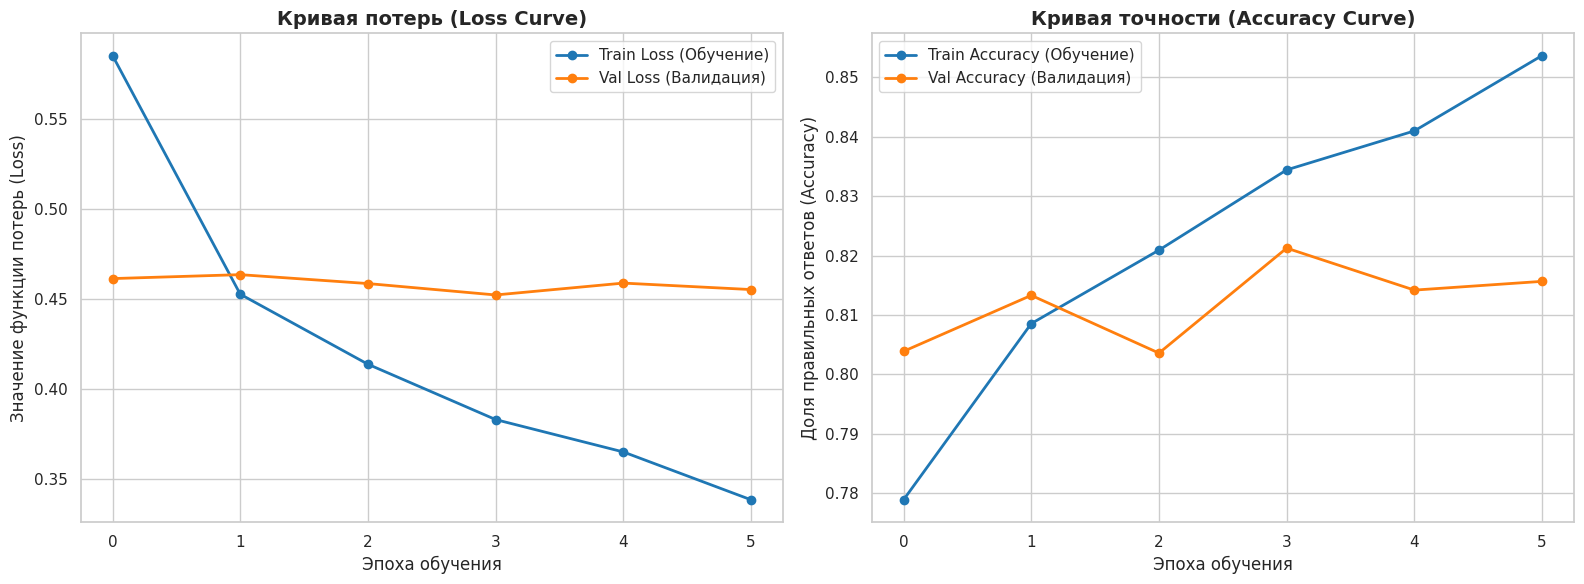

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем красивый стиль графиков
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. График Потерь (Loss)
ax[0].plot(history.history['loss'], label='Train Loss (Обучение)', color='#1f77b4', marker='o', linewidth=2)
ax[0].plot(history.history['val_loss'], label='Val Loss (Валидация)', color='#ff7f0e', marker='o', linewidth=2)
ax[0].set_title('Кривая потерь (Loss Curve)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Эпоха обучения', fontsize=12)
ax[0].set_ylabel('Значение функции потерь (Loss)', fontsize=12)
ax[0].legend(fontsize=11)

# 2. График Точности (Accuracy)
ax[1].plot(history.history['accuracy'], label='Train Accuracy (Обучение)', color='#1f77b4', marker='o', linewidth=2)
ax[1].plot(history.history['val_accuracy'], label='Val Accuracy (Валидация)', color='#ff7f0e', marker='o', linewidth=2)
ax[1].set_title('Кривая точности (Accuracy Curve)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Эпоха обучения', fontsize=12)
ax[1].set_ylabel('Доля правильных ответов (Accuracy)', fontsize=12)
ax[1].legend(fontsize=11)

plt.tight_layout()
plt.show()